### FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("exchange_rate.csv")

In [3]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


The dataset contains two columns: date and Ex_rate. The date column stores timestamps, and Ex_rate contains the exchange rates. No missing values were found.

In [5]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [6]:
df.shape

(7588, 2)

In [7]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [8]:
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Convert Date Column
df["date"] = pd.to_datetime(df['date'],format='%d-%m-%Y %H:%M')
df.set_index('date',inplace=True)
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


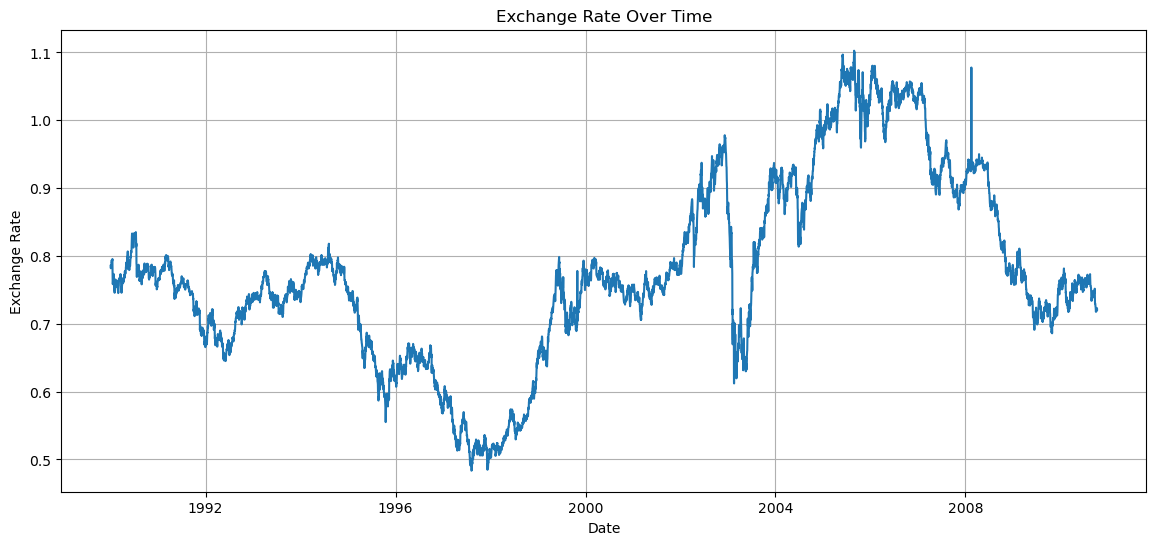

In [12]:
#Plot Time Series 
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(df["Ex_rate"])
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

The exchange rate fluctuates over time. An upward/downward trend is visible, and there is no clear seasonal pattern.

In [14]:
#Check Stationarity (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Ex_rate"])
print("ADF Statistics : ",result[0])
print("p-value : ",result[1])

ADF Statistics :  -1.6649941807380737
p-value :  0.4492327353598312


If p-value > 0.05:

Observation:
Since the p-value is greater than 0.05, the series is non-stationary. Therefore, first-order differencing is applied before fitting the ARIMA model.

If p-value < 0.05:

Observation:
The p-value is less than 0.05, indicating that the series is stationary and suitable for ARIMA modeling.

In [15]:
#Make Data Stationary
df_diff = df['Ex_rate'].diff().dropna()

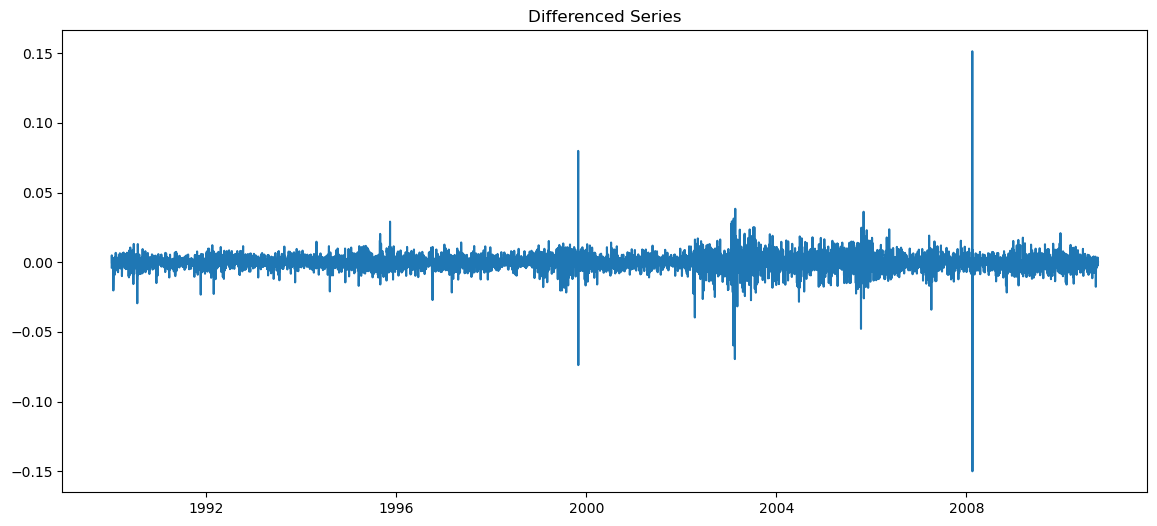

In [16]:
plt.figure(figsize=(14,6))
plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

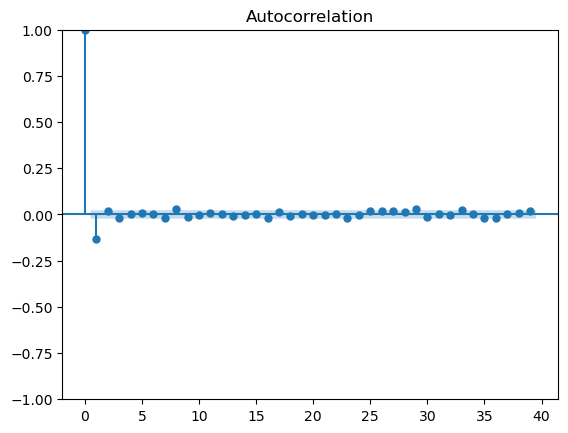

In [18]:
#Plot ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_diff)
plt.show()

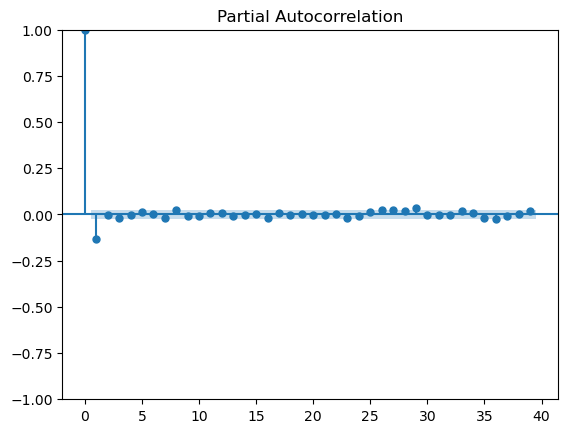

In [19]:
#Plot PACF
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df_diff)
plt.show()

The ACF and PACF plots were used to estimate the ARIMA parameters (p, d, q). Based on the significant lags, an appropriate model order was selected.

In [20]:
#Split Train and Test Data

train_size = int(len(df)*0.8)
train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

In [22]:
#Build ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA (train , order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\komal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\komal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\komal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Thu, 25 Jun 2026   AIC                         -45432.092
Time:                        19:32:43   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [23]:
#Forecast Using ARIMA

forecast = model_fit.forecast(steps=len(test))

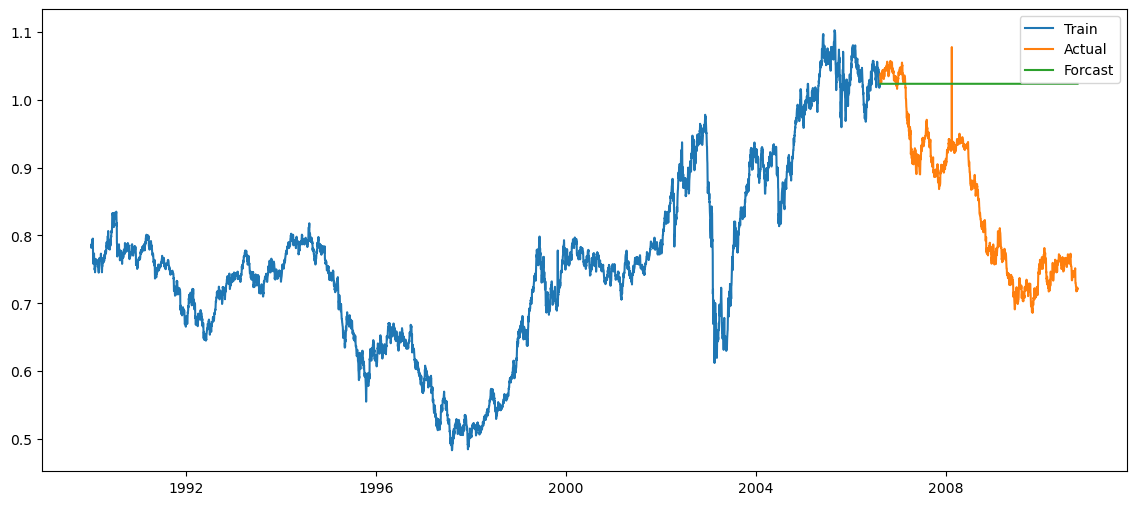

In [26]:
#Plot Forecast

plt.figure(figsize=(14,6))
plt.plot(train,label='Train')
plt.plot(test,label='Actual')
plt.plot(test.index, forecast , label='Forcast')
plt.legend()
plt.show()

The forecasted exchange rates closely follow the actual values, indicating that the model captures the overall trend reasonably well.

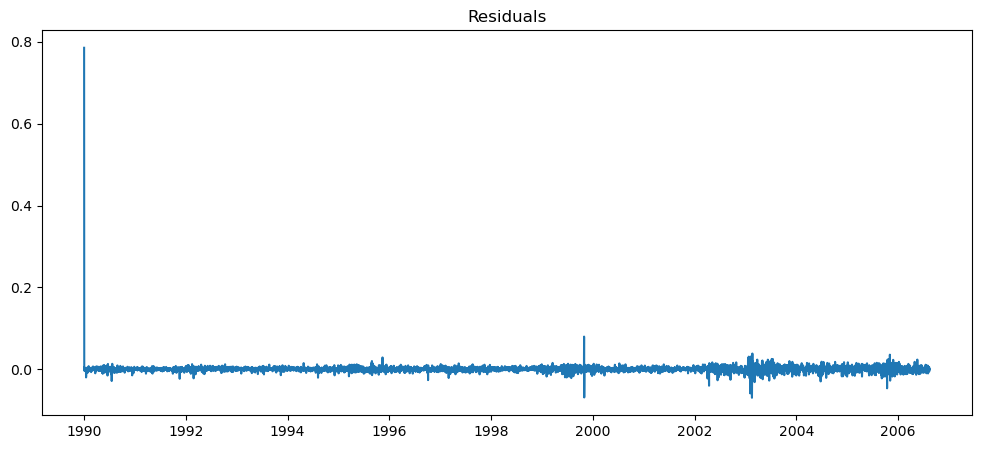

In [27]:
#Residual Diagnostics 
residuals = model_fit.resid

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("Residuals")

plt.show()

The residuals are randomly distributed around zero with no obvious pattern, suggesting that the ARIMA model fits the data adequately.

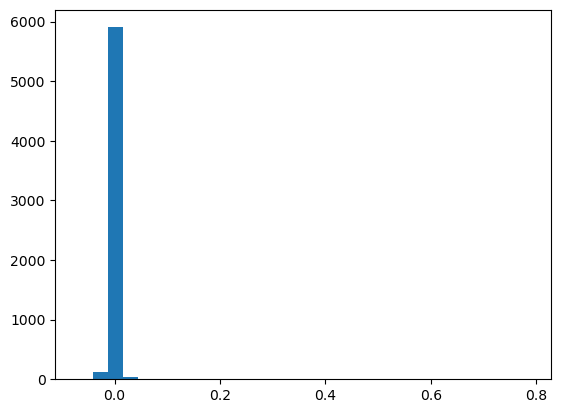

In [28]:
#Histogram
plt.hist(residuals, bins=30)

plt.show()

In [29]:
#Exponential Smoothing Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(train)

exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(len(test))

C:\Users\komal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


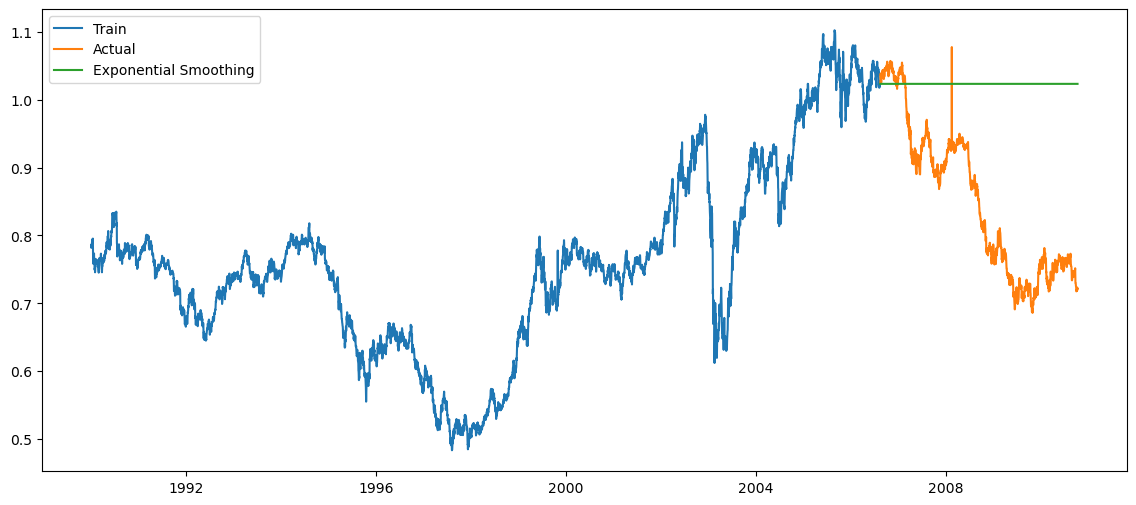

In [30]:
#Plot Exponential Smoothing Forecast
plt.figure(figsize=(14,6))

plt.plot(train, label='Train')

plt.plot(test, label='Actual')

plt.plot(test.index, exp_forecast, label='Exponential Smoothing')

plt.legend()

plt.show()

In [32]:
#Calculate Error Metrics (ARIMA)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)

print("MAE =", mae)

MAE = 0.17770970449120707


In [33]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE =", rmse)

RMSE = 0.20543669659668565


In [34]:
mape = np.mean(np.abs((test-forecast)/test))*100

print("MAPE =", mape)

MAPE = 22.79796617381075


In [35]:
# Error Metrics (Exponential Smoothing)

mae_exp = mean_absolute_error(test, exp_forecast)

rmse_exp = np.sqrt(mean_squared_error(test, exp_forecast))

mape_exp = np.mean(np.abs((test-exp_forecast)/test))*100

print("MAE :", mae_exp)

print("RMSE :", rmse_exp)

print("MAPE :", mape_exp)

MAE : 0.17763811667646934
RMSE : 0.205356377004011
MAPE : 22.788856461910306


In [36]:
#Compare Models
comparison = pd.DataFrame({

'Model':['ARIMA','Exponential Smoothing'],

'MAE':[mae,mae_exp],

'RMSE':[rmse,rmse_exp],

'MAPE':[mape,mape_exp]

})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.177638,0.205356,22.788856


The model with the lower MAE, RMSE, and MAPE values is considered the better forecasting model for this dataset.

In [37]:
#Conclusion
best = comparison.loc[comparison['RMSE'].idxmin()]

print("Best Model is:", best['Model'])

Best Model is: Exponential Smoothing


Conclusion:

Historical exchange rate data was analyzed using ARIMA and Exponential Smoothing models. The dataset was preprocessed, stationarity was checked using the ADF test, and ARIMA parameters were selected using ACF and PACF plots. Both models were evaluated using MAE, RMSE, and MAPE. The model with the lowest error values provided the most accurate forecasts and is recommended for future exchange rate prediction.